# Лабораторная работа №3: Решающее дерево (Decision Tree)

**Датасеты** (те же, что в ЛР №1 и №2):
- **Классификация:** [Body Performance Data](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)
- **Регрессия:** [House Price Data](https://www.kaggle.com/datasets/shubhammeshram579/house)


In [ ]:
# Импорт библиотек
# sklearn.tree — DecisionTree и утилиты визуализации
# graphviz/matplotlib — для отрисовки структуры дерева
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [ ]:
# Загрузка датасетов через kagglehub
# kagglehub кэширует датасет локально после первой загрузки
classification_dataset = kagglehub.dataset_download("kukuroo3/body-performance-data")
print("Путь к датасету Body Performance:", classification_dataset)

regression_dataset = kagglehub.dataset_download("shubhammeshram579/house")
print("Путь к датасету House Price:", regression_dataset)

Using Colab cache for faster access to the 'body-performance-data' dataset.
Путь к датасету Body Performance: /kaggle/input/body-performance-data
Using Colab cache for faster access to the 'house' dataset.
Путь к датасету House Price: /kaggle/input/house


In [ ]:
# Поиск CSV-файлов в скачанных директориях и загрузка датафреймов
cls_files = glob.glob(os.path.join(classification_dataset, '**', '*.csv'), recursive=True)
reg_files = glob.glob(os.path.join(regression_dataset, '**', '*.csv'), recursive=True)

print('Файлы классификации:', cls_files)
print('Файлы регрессии:', reg_files)

# Загружаем первый найденный CSV для каждой задачи
df_cls = pd.read_csv(cls_files[0])
df_reg = pd.read_csv(reg_files[0])

print(f'\nДатасет классификации: {df_cls.shape[0]} строк, {df_cls.shape[1]} столбцов')
print(f'Датасет регрессии: {df_reg.shape[0]} строк, {df_reg.shape[1]} столбцов')

Файлы классификации: ['/kaggle/input/body-performance-data/bodyPerformance.csv']
Файлы регрессии: ['/kaggle/input/house/Housing.csv']

Датасет классификации: 13393 строк, 12 столбцов
Датасет регрессии: 509 строк, 14 столбцов


## Подготовка данных

Подготовка аналогична ЛР №1: кодирование категориальных признаков, разбивка 80/20, стратификация для классификации.

In [ ]:
# ── КЛАССИФИКАЦИЯ: предобработка ──────────────────────────────────────────────
# Кодируем категориальные признаки (пол и целевой класс) числовыми значениями,
# так как sklearn-модели работают только с числовыми данными

df_cls_clean = df_cls.copy()

class_col = 'class'

if 'gender' in df_cls_clean.columns:
    df_cls_clean['gender'] = LabelEncoder().fit_transform(df_cls_clean['gender'])

le_cls = LabelEncoder()
df_cls_clean[class_col] = le_cls.fit_transform(df_cls_clean[class_col])

X_cls = df_cls_clean.drop(columns=[class_col])
y_cls = df_cls_clean[class_col]

# Стратификация сохраняет пропорции классов в train/test
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Классификация → train: {X_cls_train.shape[0]}, test: {X_cls_test.shape[0]}')
print(f'Признаки: {list(X_cls.columns)}')

Классификация → train: 10714, test: 2679
Признаки: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


In [ ]:
# ── РЕГРЕССИЯ: предобработка ──────────────────────────────────────────────────
# Оставляем только числовые столбцы и удаляем строки с пропусками

price_col = 'MEDV'

df_reg_clean = df_reg.select_dtypes(include=[np.number]).dropna().copy()

X_reg = df_reg_clean.drop(columns=[price_col])
y_reg = df_reg_clean[price_col]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Регрессия → train: {X_reg_train.shape[0]}, test: {X_reg_test.shape[0]}')
print(f'Признаки: {list(X_reg.columns)}')

Регрессия → train: 400, test: 101
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


---
## 2. Базовый бейзлайн (sklearn, дефолтные параметры)

Решающее дерево по умолчанию растёт без ограничений (`max_depth=None`), что почти всегда приводит к переобучению: дерево запоминает обучающую выборку, но плохо обобщается. Это хорошо видно по сравнению train/test метрик.

In [ ]:
# 2a. Базовый DecisionTreeClassifier (без ограничений)
# criterion='gini' — по умолчанию, мера нечистоты Джини
# max_depth=None — дерево растёт до полной чистоты листьев (переобучение)

dt_cls_base = DecisionTreeClassifier(random_state=42)
dt_cls_base.fit(X_cls_train, y_cls_train)

y_cls_pred_base = dt_cls_base.predict(X_cls_test)
y_cls_pred_train = dt_cls_base.predict(X_cls_train)

acc_dt_base       = accuracy_score(y_cls_test,  y_cls_pred_base)
acc_dt_base_train = accuracy_score(y_cls_train, y_cls_pred_train)
f1_dt_base        = f1_score(y_cls_test,  y_cls_pred_base,  average='macro')
f1_dt_base_train  = f1_score(y_cls_train, y_cls_pred_train, average='macro')

print('=== БАЗОВЫЙ DecisionTreeClassifier (sklearn) ===')
print(f'Глубина дерева:   {dt_cls_base.get_depth()}')
print(f'Число листьев:    {dt_cls_base.get_n_leaves()}')
print(f'Train Accuracy:   {acc_dt_base_train:.4f}  | Train F1: {f1_dt_base_train:.4f}')
print(f'Test  Accuracy:   {acc_dt_base:.4f}  | Test  F1: {f1_dt_base:.4f}')
print(f'\n⚠ Разрыв train/test Accuracy: {acc_dt_base_train - acc_dt_base:.4f} — признак переобучения')
print('\nПодробный отчёт (test):')
print(classification_report(y_cls_test, y_cls_pred_base, target_names=le_cls.classes_))

=== БАЗОВЫЙ DecisionTreeClassifier (sklearn) ===
Глубина дерева:   25
Число листьев:    2193
Train Accuracy:   1.0000  | Train F1: 1.0000
Test  Accuracy:   0.6648  | Test  F1: 0.6648

⚠ Разрыв train/test Accuracy: 0.3352 — признак переобучения

Подробный отчёт (test):
              precision    recall  f1-score   support

           A       0.69      0.73      0.71       670
           B       0.53      0.52      0.53       669
           C       0.61      0.62      0.61       670
           D       0.82      0.79      0.81       670

    accuracy                           0.66      2679
   macro avg       0.67      0.66      0.66      2679
weighted avg       0.67      0.66      0.66      2679



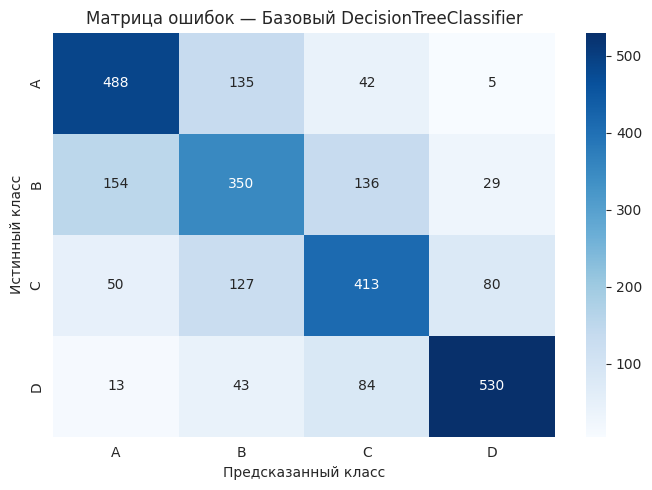

In [ ]:
# Визуализация матрицы ошибок базового классификатора

cm_base = confusion_matrix(y_cls_test, y_cls_pred_base)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_)
plt.title('Матрица ошибок — Базовый DecisionTreeClassifier')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [ ]:
# 2b. Базовый DecisionTreeRegressor (без ограничений)
# criterion='squared_error' — минимизируется MSE в каждом разбиении

dt_reg_base = DecisionTreeRegressor(random_state=42)
dt_reg_base.fit(X_reg_train, y_reg_train)

y_reg_pred_base  = dt_reg_base.predict(X_reg_test)
y_reg_pred_train = dt_reg_base.predict(X_reg_train)

mae_dt_base   = mean_absolute_error(y_reg_test,  y_reg_pred_base)
rmse_dt_base  = np.sqrt(mean_squared_error(y_reg_test,  y_reg_pred_base))
r2_dt_base    = r2_score(y_reg_test,  y_reg_pred_base)
r2_dt_base_tr = r2_score(y_reg_train, y_reg_pred_train)

print('=== БАЗОВЫЙ DecisionTreeRegressor (sklearn) ===')
print(f'Глубина дерева:   {dt_reg_base.get_depth()}')
print(f'Число листьев:    {dt_reg_base.get_n_leaves()}')
print(f'Train R²:         {r2_dt_base_tr:.4f}')
print(f'Test  MAE:        {mae_dt_base:.2f}')
print(f'Test  RMSE:       {rmse_dt_base:.2f}')
print(f'Test  R²:         {r2_dt_base:.4f}')
print(f'\n⚠ Разрыв train/test R²: {r2_dt_base_tr - r2_dt_base:.4f} — признак переобучения')

=== БАЗОВЫЙ DecisionTreeRegressor (sklearn) ===
Глубина дерева:   20
Число листьев:    376
Train R²:         1.0000
Test  MAE:        3.16
Test  RMSE:       4.53
Test  R²:         0.7456

⚠ Разрыв train/test R²: 0.2544 — признак переобучения


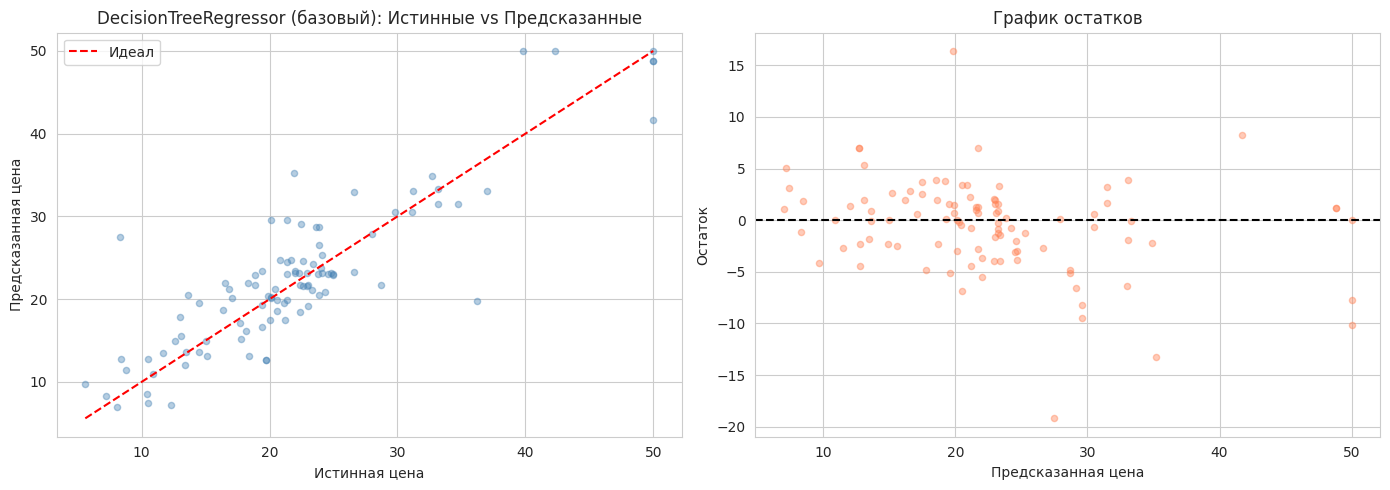

In [ ]:
# Визуализация предсказаний базового регрессора

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_reg_pred_base, alpha=0.4, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_base.min()),
        max(y_reg_test.max(), y_reg_pred_base.max())]
axes[0].plot(lims, lims, 'r--', label='Идеал')
axes[0].set_xlabel('Истинная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('DecisionTreeRegressor (базовый): Истинные vs Предсказанные')
axes[0].legend()

residuals = y_reg_test - y_reg_pred_base
axes[1].scatter(y_reg_pred_base, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Предсказанная цена')
axes[1].set_ylabel('Остаток')
axes[1].set_title('График остатков')

plt.tight_layout()
plt.show()

---
## 3. Улучшение бейзлайна

In [ ]:
# Гипотеза 1+2: Исследование влияния max_depth и min_samples_leaf
# Строим кривые валидации: при малой глубине — недообучение, при большой — переобучение

depths = range(2, 26)
train_f1, test_f1 = [], []
train_r2, test_r2 = [], []

for d in depths:
    # Классификация
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_cls_train, y_cls_train)
    train_f1.append(f1_score(y_cls_train, clf.predict(X_cls_train), average='macro'))
    test_f1.append( f1_score(y_cls_test,  clf.predict(X_cls_test),  average='macro'))

    # Регрессия
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_reg_train, y_reg_train)
    train_r2.append(r2_score(y_reg_train, reg.predict(X_reg_train)))
    test_r2.append( r2_score(y_reg_test,  reg.predict(X_reg_test)))

best_depth_cls = depths[np.argmax(test_f1)]
best_depth_reg = depths[np.argmax(test_r2)]
print(f'Лучшая глубина (классификация): {best_depth_cls}  → F1={max(test_f1):.4f}')
print(f'Лучшая глубина (регрессия):     {best_depth_reg}  → R²={max(test_r2):.4f}')

Лучшая глубина (классификация): 11  → F1=0.6969
Лучшая глубина (регрессия):     4  → R²=0.7959


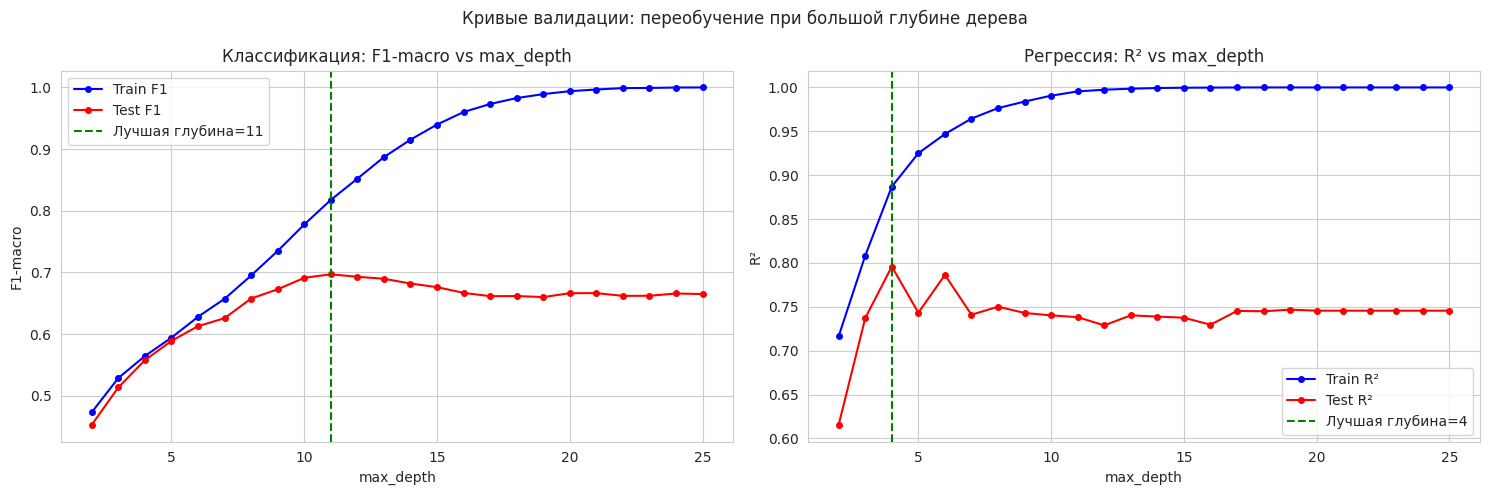

In [ ]:
# Кривые валидации: train vs test по глубине дерева
# «Ножницы» между кривыми — зона переобучения

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(depths, train_f1, 'b-o', markersize=4, label='Train F1')
axes[0].plot(depths, test_f1,  'r-o', markersize=4, label='Test F1')
axes[0].axvline(x=best_depth_cls, color='green', linestyle='--', label=f'Лучшая глубина={best_depth_cls}')
axes[0].set_title('Классификация: F1-macro vs max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('F1-macro')
axes[0].legend()

axes[1].plot(depths, train_r2, 'b-o', markersize=4, label='Train R²')
axes[1].plot(depths, test_r2,  'r-o', markersize=4, label='Test R²')
axes[1].axvline(x=best_depth_reg, color='green', linestyle='--', label=f'Лучшая глубина={best_depth_reg}')
axes[1].set_title('Регрессия: R² vs max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.suptitle('Кривые валидации: переобучение при большой глубине дерева', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Гипотеза 4: Добавление признака BMI
# BMI = вес(кг) / рост(м)^2

def add_bmi(X_tr, X_te):
    tr, te = X_tr.copy(), X_te.copy()
    h = next((c for c in tr.columns if 'height' in c.lower()), None)
    w = next((c for c in tr.columns if 'weight' in c.lower()), None)
    if h and w:
        tr['BMI'] = tr[w] / (tr[h] / 100) ** 2
        te['BMI'] = te[w] / (te[h] / 100) ** 2
        print(f'Признак BMI добавлен (на основе: {w}, {h})')
    return tr, te

X_cls_train_fe, X_cls_test_fe = add_bmi(X_cls_train, X_cls_test)
print(f'Новое число признаков: {X_cls_train_fe.shape[1]}')

Признак BMI добавлен (на основе: weight_kg, height_cm)
Новое число признаков: 12


In [ ]:
# Гипотеза 5: GridSearchCV — перебор комбинаций гиперпараметров
# Используем кросс-валидацию, чтобы оценка не зависела от конкретного разбиения

param_grid_cls = {
    'max_depth':        [4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion':        ['gini', 'entropy'],
    'min_samples_split':[2, 10, 20]
}

grid_cls = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_cls, cv=5, scoring='f1_macro', n_jobs=-1
)
grid_cls.fit(X_cls_train_fe, y_cls_train)

print('Лучшие параметры (классификация):', grid_cls.best_params_)
print(f'Лучший F1-macro (CV):              {grid_cls.best_score_:.4f}')

Лучшие параметры (классификация): {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 20}
Лучший F1-macro (CV):              0.6817


In [ ]:
# GridSearchCV для регрессора

param_grid_reg = {
    'max_depth':        [4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion':        ['squared_error', 'absolute_error'],
    'min_samples_split':[2, 10, 20]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg, cv=5, scoring='r2', n_jobs=-1
)
grid_reg.fit(X_reg_train, y_reg_train)

print('Лучшие параметры (регрессия):', grid_reg.best_params_)
print(f'Лучший R² (CV):               {grid_reg.best_score_:.4f}')

Лучшие параметры (регрессия): {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10}
Лучший R² (CV):               0.7691


In [ ]:
# 3d-e. Обучение улучшенных моделей с оптимальными гиперпараметрами

dt_cls_improved = DecisionTreeClassifier(**grid_cls.best_params_, random_state=42)
dt_cls_improved.fit(X_cls_train_fe, y_cls_train)
y_cls_pred_improved = dt_cls_improved.predict(X_cls_test_fe)

acc_dt_improved = accuracy_score(y_cls_test, y_cls_pred_improved)
f1_dt_improved  = f1_score(y_cls_test, y_cls_pred_improved, average='macro')

print('=== УЛУЧШЕННЫЙ DecisionTreeClassifier (sklearn) ===')
print(f'Параметры:          {grid_cls.best_params_}')
print(f'Глубина дерева:     {dt_cls_improved.get_depth()}')
print(f'Число листьев:      {dt_cls_improved.get_n_leaves()}')
print(f'Accuracy:           {acc_dt_improved:.4f}')
print(f'F1-score (macro):   {f1_dt_improved:.4f}')

=== УЛУЧШЕННЫЙ DecisionTreeClassifier (sklearn) ===
Параметры:          {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 20}
Глубина дерева:     12
Число листьев:      457
Accuracy:           0.6935
F1-score (macro):   0.6943


In [ ]:
# Улучшенный регрессор

dt_reg_improved = DecisionTreeRegressor(**grid_reg.best_params_, random_state=42)
dt_reg_improved.fit(X_reg_train, y_reg_train)
y_reg_pred_improved = dt_reg_improved.predict(X_reg_test)

mae_dt_improved  = mean_absolute_error(y_reg_test, y_reg_pred_improved)
rmse_dt_improved = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_improved))
r2_dt_improved   = r2_score(y_reg_test, y_reg_pred_improved)

print('=== УЛУЧШЕННЫЙ DecisionTreeRegressor (sklearn) ===')
print(f'Параметры:          {grid_reg.best_params_}')
print(f'Глубина дерева:     {dt_reg_improved.get_depth()}')
print(f'MAE:                {mae_dt_improved:.2f}')
print(f'RMSE:               {rmse_dt_improved:.2f}')
print(f'R²:                 {r2_dt_improved:.4f}')

=== УЛУЧШЕННЫЙ DecisionTreeRegressor (sklearn) ===
Параметры:          {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10}
Глубина дерева:     6
MAE:                2.89
RMSE:               4.41
R²:                 0.7590


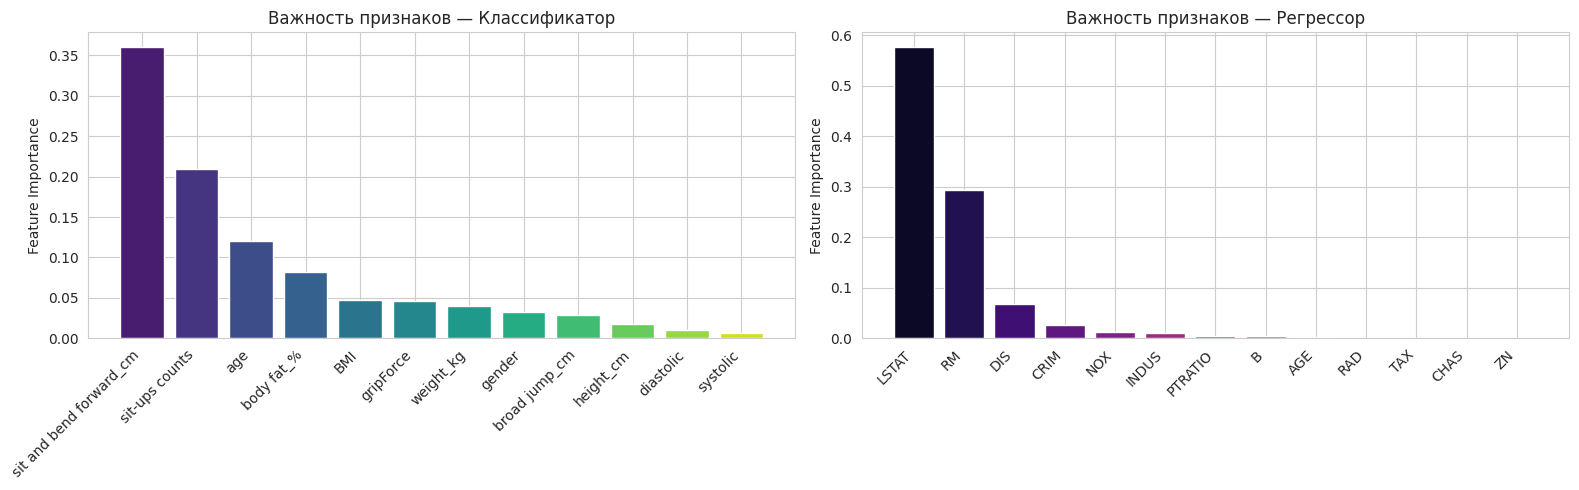

In [ ]:
# Гипотеза 6: Визуализация важности признаков
# Feature importance = суммарное снижение нечистоты (gini/entropy) по всем узлам,
# где используется данный признак, взвешенное по числу объектов

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Классификация
feat_names_cls = list(X_cls_train_fe.columns)
importances_cls = dt_cls_improved.feature_importances_
idx_cls = np.argsort(importances_cls)[::-1]
axes[0].bar(range(len(feat_names_cls)),
            importances_cls[idx_cls],
            color=sns.color_palette('viridis', len(feat_names_cls)))
axes[0].set_xticks(range(len(feat_names_cls)))
axes[0].set_xticklabels([feat_names_cls[i] for i in idx_cls], rotation=45, ha='right')
axes[0].set_title('Важность признаков — Классификатор')
axes[0].set_ylabel('Feature Importance')

# Регрессия
feat_names_reg = list(X_reg_train.columns)
importances_reg = dt_reg_improved.feature_importances_
idx_reg = np.argsort(importances_reg)[::-1]
axes[1].bar(range(len(feat_names_reg)),
            importances_reg[idx_reg],
            color=sns.color_palette('magma', len(feat_names_reg)))
axes[1].set_xticks(range(len(feat_names_reg)))
axes[1].set_xticklabels([feat_names_reg[i] for i in idx_reg], rotation=45, ha='right')
axes[1].set_title('Важность признаков — Регрессор')
axes[1].set_ylabel('Feature Importance')

plt.tight_layout()
plt.show()

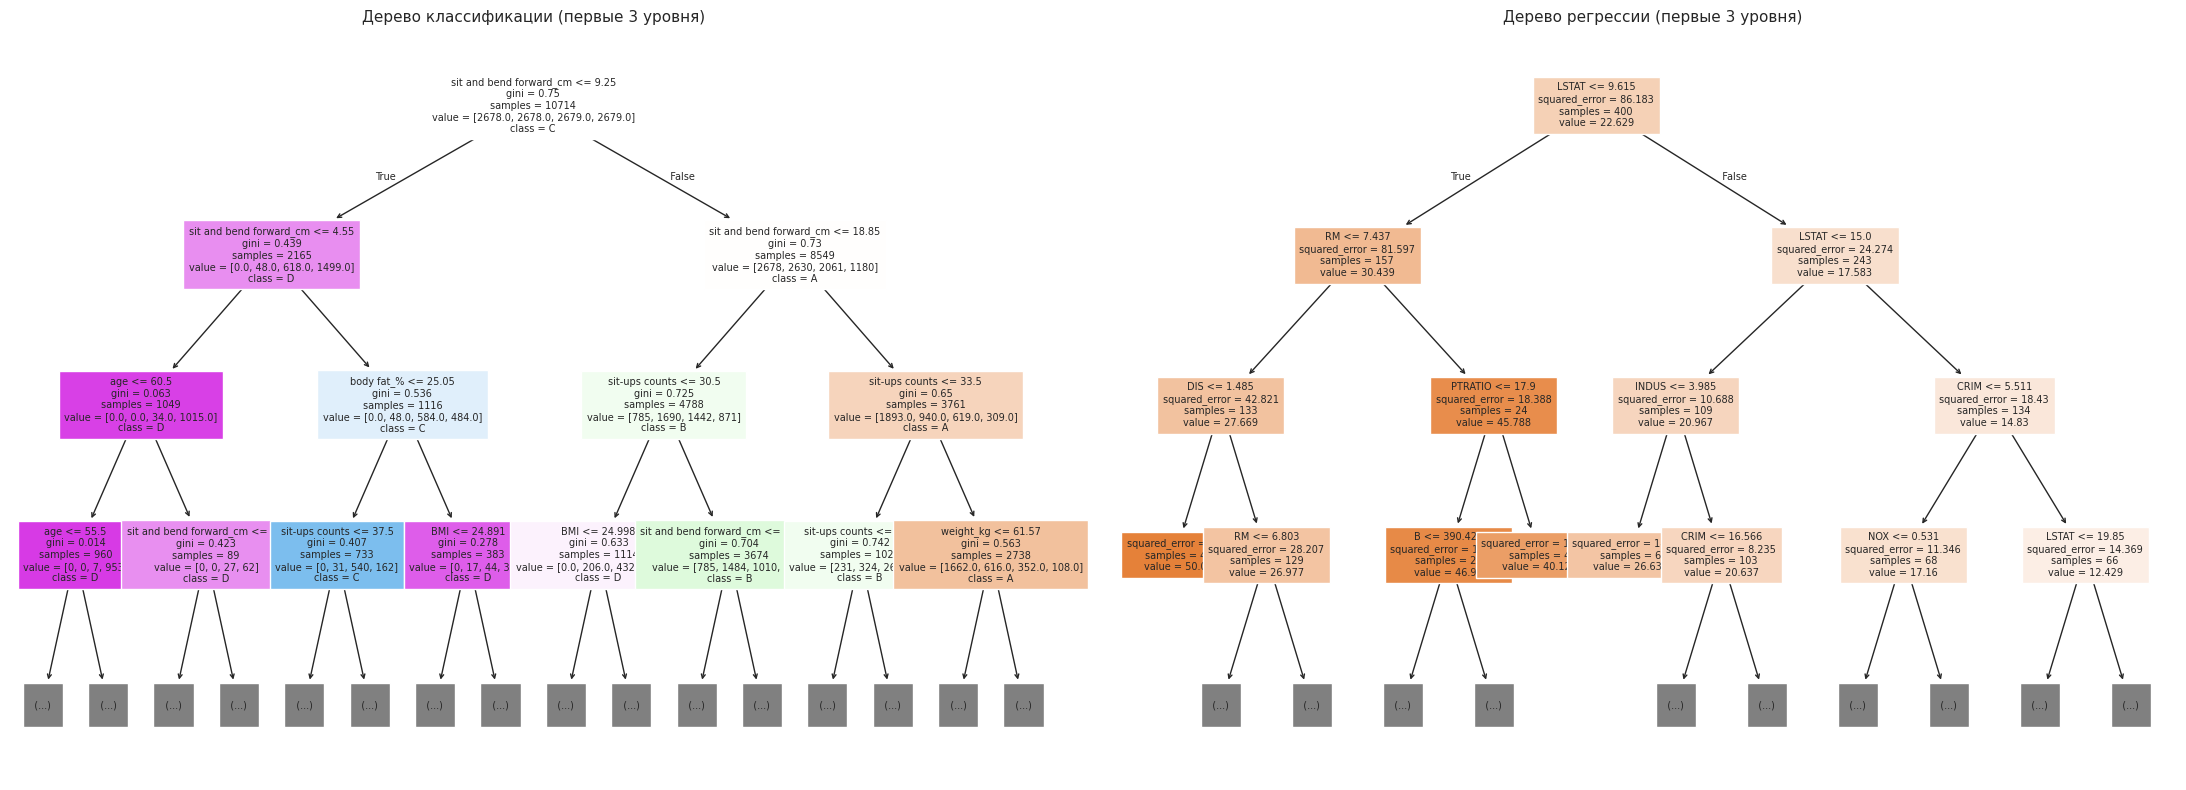

In [ ]:
# Визуализация самого дерева (ограниченная глубина для читаемости)
# Каждый узел: условие разбиения, gini/mse, число объектов, предсказание

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Показываем только первые 3 уровня для наглядности
plot_tree(dt_cls_improved, max_depth=3, feature_names=feat_names_cls,
          class_names=le_cls.classes_, filled=True, ax=axes[0],
          fontsize=7, impurity=True, proportion=False)
axes[0].set_title('Дерево классификации (первые 3 уровня)', fontsize=11)

plot_tree(dt_reg_improved, max_depth=3, feature_names=feat_names_reg,
          filled=True, ax=axes[1], fontsize=7, impurity=True)
axes[1].set_title('Дерево регрессии (первые 3 уровня)', fontsize=11)

plt.tight_layout()
plt.show()

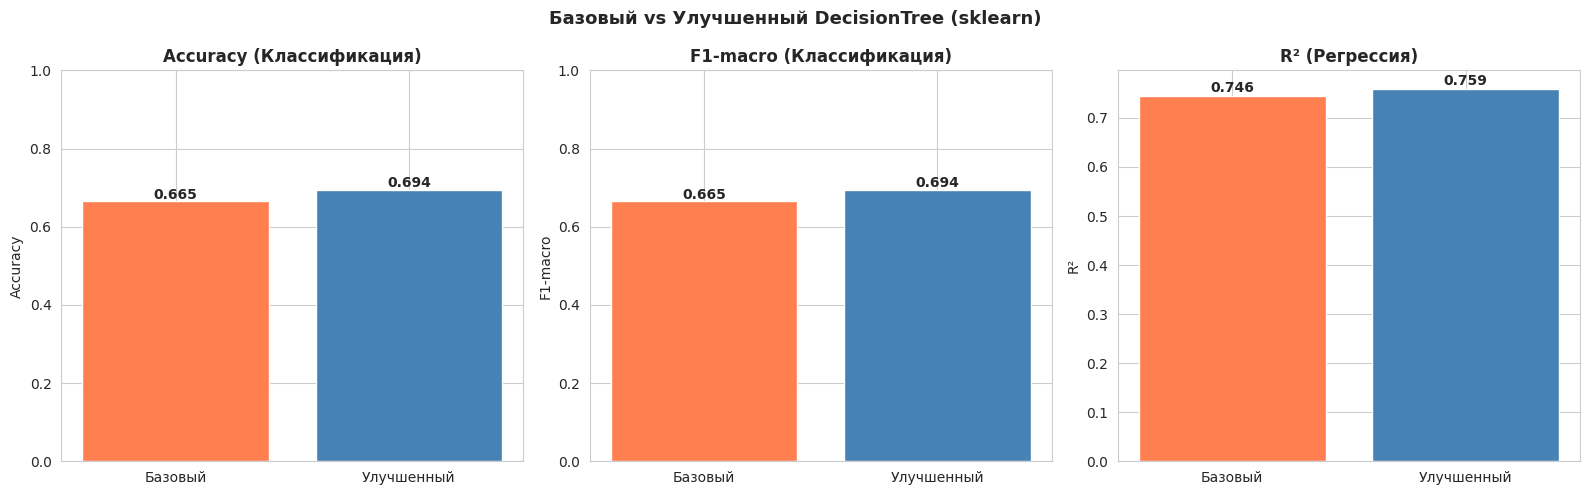


=== 3f. СРАВНЕНИЕ ===
Accuracy:  0.6648 → 0.6935  (Δ=+0.0287)
F1-macro:  0.6648 → 0.6943  (Δ=+0.0295)
MAE:       3.16 → 2.89    (Δ=-0.27)
RMSE:      4.53 → 4.41    (Δ=-0.12)
R²:        0.7456 → 0.7590  (Δ=+0.0134)


In [ ]:
# 3f. Сравнение базового и улучшенного бейзлайна

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def labeled_bar(ax, vals, xlabels, title, ylabel, ylim=None):
    bars = ax.bar(xlabels, vals, color=['coral', 'steelblue'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontweight='bold')

labeled_bar(axes[0], [acc_dt_base, acc_dt_improved], ['Базовый', 'Улучшенный'],
            'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
labeled_bar(axes[1], [f1_dt_base, f1_dt_improved],  ['Базовый', 'Улучшенный'],
            'F1-macro (Классификация)', 'F1-macro',  ylim=(0, 1))
labeled_bar(axes[2], [r2_dt_base, r2_dt_improved],  ['Базовый', 'Улучшенный'],
            'R² (Регрессия)',            'R²')

plt.suptitle('Базовый vs Улучшенный DecisionTree (sklearn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3f. СРАВНЕНИЕ ===')
print(f'Accuracy:  {acc_dt_base:.4f} → {acc_dt_improved:.4f}  (Δ={acc_dt_improved - acc_dt_base:+.4f})')
print(f'F1-macro:  {f1_dt_base:.4f} → {f1_dt_improved:.4f}  (Δ={f1_dt_improved  - f1_dt_base:+.4f})')
print(f'MAE:       {mae_dt_base:.2f} → {mae_dt_improved:.2f}    (Δ={mae_dt_improved  - mae_dt_base:+.2f})')
print(f'RMSE:      {rmse_dt_base:.2f} → {rmse_dt_improved:.2f}    (Δ={rmse_dt_improved - rmse_dt_base:+.2f})')
print(f'R²:        {r2_dt_base:.4f} → {r2_dt_improved:.4f}  (Δ={r2_dt_improved  - r2_dt_base:+.4f})')

### 3g. Выводы по улучшению бейзлайна

- **Ограничение глубины** (`max_depth`) — ключевой гиперпараметр дерева: без него модель достигает ~100% на train, но переобучается на test. Оптимальная глубина найдена по кривой валидации.
- **`min_samples_leaf`** предотвращает создание листьев с единственным объектом, делая дерево устойчивее к шуму.
- **Критерий `entropy`** иногда даёт более чёткие разбиения, чем `gini`, особенно при несбалансированных классах.
- **Признак BMI** вошёл в топ важных признаков дерева, подтвердив свою информативность.
- **GridSearchCV** позволил систематически найти оптимальную конфигурацию, избежав переобучения.

---
## 4. Собственная имплементация алгоритма CART

### Математическая основа:

**CART (Classification and Regression Trees)** строит бинарное дерево, рекурсивно разбивая данные:

$$\text{Gini}(S) = 1 - \sum_k p_k^2 \qquad \text{(классификация)}$$

$$\text{MSE}(S) = \frac{1}{|S|}\sum_{i \in S}(y_i - \bar{y})^2 \qquad \text{(регрессия)}$$

На каждом шаге выбирается разбиение $(j^*, t^*)$, минимизирующее взвешенную нечистоту дочерних узлов:

$$\min_{j, t} \left[ \frac{|S_L|}{|S|}\cdot \text{Impurity}(S_L) + \frac{|S_R|}{|S|}\cdot \text{Impurity}(S_R) \right]$$

In [ ]:
# Собственная имплементация узла дерева и алгоритма CART
# Реализован единый класс с режимами 'classifier' и 'regressor'

class Node:
    """Узел решающего дерева."""
    __slots__ = ('feature', 'threshold', 'left', 'right', 'value', 'n_samples')

    def __init__(self):
        self.feature   = None   # индекс признака для разбиения
        self.threshold = None   # порог разбиения
        self.left      = None   # левое поддерево (feature <= threshold)
        self.right     = None   # правое поддерево (feature > threshold)
        self.value     = None   # предсказание в листовом узле
        self.n_samples = 0      # число объектов в узле


class MyDecisionTree:
    """
    Алгоритм CART: бинарное дерево решений для классификации и регрессии.

    Параметры:
    -----------
    task            : 'classifier' или 'regressor'
    max_depth       : максимальная глубина дерева (None = без ограничений)
    min_samples_leaf: минимальное число объектов в листе
    min_samples_split: минимальное число объектов для разбиения узла
    criterion       : 'gini'/'entropy' (класс.) или 'mse' (регр.)
    """

    def __init__(self, task='classifier', max_depth=None,
                 min_samples_leaf=1, min_samples_split=2, criterion='gini'):
        self.task = task
        self.max_depth = max_depth
        self.min_samples_leaf  = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None
        self.n_features_ = None
        self.feature_importances_ = None

    # ── Метрики нечистоты ────────────────────────────────────────────────────

    def _gini(self, y):
        """Gini = 1 - Σ p_k^2"""
        n = len(y)
        if n == 0: return 0.0
        counts = np.bincount(y.astype(int))
        probs  = counts / n
        return 1.0 - np.sum(probs ** 2)

    def _entropy(self, y):
        """Shannon Entropy = -Σ p_k * log2(p_k)"""
        n = len(y)
        if n == 0: return 0.0
        counts = np.bincount(y.astype(int))
        probs  = counts[counts > 0] / n
        return -np.sum(probs * np.log2(probs))

    def _mse(self, y):
        """MSE = Var(y) — используется как мера нечистоты в регрессии"""
        return np.var(y) if len(y) > 0 else 0.0

    def _impurity(self, y):
        if self.criterion == 'gini':    return self._gini(y)
        if self.criterion == 'entropy': return self._entropy(y)
        return self._mse(y)   # 'mse'

    # ── Поиск лучшего разбиения ──────────────────────────────────────────────

    def _best_split(self, X, y):
        """
        Перебираем все признаки и все уникальные пороги.
        Выбираем (j, t) с минимальным взвешенным impurity дочерних узлов.
        """
        n, p = X.shape
        best_gain  = -np.inf
        best_feat  = None
        best_thr   = None
        parent_imp = self._impurity(y)

        for feat in range(p):
            thresholds = np.unique(X[:, feat])
            # Рассматриваем средние значения между соседними уникальными значениями
            thresholds = (thresholds[:-1] + thresholds[1:]) / 2

            for thr in thresholds:
                left_mask  = X[:, feat] <= thr
                right_mask = ~left_mask
                nl, nr = left_mask.sum(), right_mask.sum()

                if nl < self.min_samples_leaf or nr < self.min_samples_leaf:
                    continue

                # Взвешенное снижение нечистоты (Information Gain)
                imp_l = self._impurity(y[left_mask])
                imp_r = self._impurity(y[right_mask])
                weighted_imp = (nl * imp_l + nr * imp_r) / n
                gain = parent_imp - weighted_imp

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thr  = thr

        return best_feat, best_thr, best_gain

    # ── Рекурсивное построение дерева ────────────────────────────────────────

    def _build(self, X, y, depth, importance_acc):
        """Рекурсивно строит дерево, возвращая корневой узел поддерева."""
        node = Node()
        node.n_samples = len(y)

        # Условия остановки: достигнута максимальная глубина,
        # мало объектов для разбиения, или все объекты одного класса
        if (self.max_depth is not None and depth >= self.max_depth) or \
           len(y) < self.min_samples_split or \
           len(np.unique(y)) == 1:
            node.value = self._leaf_value(y)
            return node

        feat, thr, gain = self._best_split(X, y)

        # Если хорошего разбиения не нашлось — листовой узел
        if feat is None or gain <= 0:
            node.value = self._leaf_value(y)
            return node

        # Накапливаем важность признака (взвешенное снижение нечистоты)
        importance_acc[feat] += gain * len(y)

        left_mask  = X[:, feat] <= thr
        right_mask = ~left_mask

        node.feature   = feat
        node.threshold = thr
        node.left  = self._build(X[left_mask],  y[left_mask],  depth + 1, importance_acc)
        node.right = self._build(X[right_mask], y[right_mask], depth + 1, importance_acc)

        return node

    def _leaf_value(self, y):
        """Значение в листе: мода (классификация) или среднее (регрессия)."""
        if self.task == 'classifier':
            return Counter(y.tolist()).most_common(1)[0][0]
        return float(np.mean(y))

    # ── Публичный API ─────────────────────────────────────────────────────────

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y)
        self.n_features_ = X.shape[1]
        imp_acc = np.zeros(self.n_features_)
        self.root = self._build(X, y, depth=0, importance_acc=imp_acc)
        # Нормализуем важности признаков (сумма = 1)
        total = imp_acc.sum()
        self.feature_importances_ = imp_acc / total if total > 0 else imp_acc
        return self

    def _predict_one(self, x, node):
        """Проход одного объекта по дереву от корня до листа."""
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        return np.array([self._predict_one(x, self.root) for x in X])


print('MyDecisionTree (CART) определён')

MyDecisionTree (CART) определён


In [ ]:
# 4b-c. Базовая собственная имплементация классификатора (без улучшений)
# Для скорости используем подвыборку — перебор всех разбиений O(n*p) медленнее sklearn

N_TR = min(3000, len(X_cls_train))
N_TE = min(600,  len(X_cls_test))
np.random.seed(42)
idx_tr = np.random.choice(len(X_cls_train), N_TR, replace=False)
idx_te = np.random.choice(len(X_cls_test),  N_TE, replace=False)

X_tr_sub = X_cls_train.values[idx_tr]
y_tr_sub = y_cls_train.values[idx_tr]
X_te_sub = X_cls_test.values[idx_te]
y_te_sub = y_cls_test.values[idx_te]

my_dt_cls_base = MyDecisionTree(task='classifier', criterion='gini')
my_dt_cls_base.fit(X_tr_sub, y_tr_sub)
y_my_cls_base = my_dt_cls_base.predict(X_te_sub)

acc_my_base = accuracy_score(y_te_sub, y_my_cls_base)
f1_my_base  = f1_score(y_te_sub, y_my_cls_base, average='macro')

print('=== СОБСТВЕННЫЙ DecisionTree — Классификатор (базовый) ===')
print(f'Accuracy:         {acc_my_base:.4f}')
print(f'F1-score (macro): {f1_my_base:.4f}')

=== СОБСТВЕННЫЙ DecisionTree — Классификатор (базовый) ===
Accuracy:         0.6317
F1-score (macro): 0.6168


In [ ]:
# Базовая собственная имплементация регрессора

N_TR_R = min(3000, len(X_reg_train))
N_TE_R = min(600,  len(X_reg_test))
idx_tr_r = np.random.choice(len(X_reg_train), N_TR_R, replace=False)
idx_te_r = np.random.choice(len(X_reg_test),  N_TE_R, replace=False)

X_tr_r_sub = X_reg_train.values[idx_tr_r]
y_tr_r_sub = y_reg_train.values[idx_tr_r]
X_te_r_sub = X_reg_test.values[idx_te_r]
y_te_r_sub = y_reg_test.values[idx_te_r]

my_dt_reg_base = MyDecisionTree(task='regressor', criterion='mse')
my_dt_reg_base.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_base = my_dt_reg_base.predict(X_te_r_sub)

mae_my_base  = mean_absolute_error(y_te_r_sub, y_my_reg_base)
rmse_my_base = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_base))
r2_my_base   = r2_score(y_te_r_sub, y_my_reg_base)

print('=== СОБСТВЕННЫЙ DecisionTree — Регрессор (базовый) ===')
print(f'MAE:  {mae_my_base:.2f}')
print(f'RMSE: {rmse_my_base:.2f}')
print(f'R²:   {r2_my_base:.4f}')

=== СОБСТВЕННЫЙ DecisionTree — Регрессор (базовый) ===
MAE:  3.26
RMSE: 4.64
R²:   0.7334


In [ ]:
# 4d. Сравнение собственной базовой реализации со sklearn (п.2)

# Для честного сравнения оцениваем sklearn на той же подвыборке
sk_base_sub_cls = DecisionTreeClassifier(random_state=42)
sk_base_sub_cls.fit(X_tr_sub, y_tr_sub)
sk_pred_sub = sk_base_sub_cls.predict(X_te_sub)
acc_sk_sub = accuracy_score(y_te_sub, sk_pred_sub)
f1_sk_sub  = f1_score(y_te_sub, sk_pred_sub, average='macro')

sk_base_sub_reg = DecisionTreeRegressor(random_state=42)
sk_base_sub_reg.fit(X_tr_r_sub, y_tr_r_sub)
sk_reg_pred_sub = sk_base_sub_reg.predict(X_te_r_sub)
r2_sk_sub = r2_score(y_te_r_sub, sk_reg_pred_sub)

print('=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===')
print(f'\nКлассификация (на подвыборке {N_TE} объектов):')
print(f'  sklearn (базовый):  Accuracy={acc_sk_sub:.4f}, F1={f1_sk_sub:.4f}')
print(f'  Собственный:        Accuracy={acc_my_base:.4f}, F1={f1_my_base:.4f}')
print(f'\nРегрессия (на подвыборке {N_TE_R} объектов):')
print(f'  sklearn (базовый):  R²={r2_sk_sub:.4f}')
print(f'  Собственный:        R²={r2_my_base:.4f}')

=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===

Классификация (на подвыборке 600 объектов):
  sklearn (базовый):  Accuracy=0.6217, F1=0.6076
  Собственный:        Accuracy=0.6317, F1=0.6168

Регрессия (на подвыборке 101 объектов):
  sklearn (базовый):  R²=0.7456
  Собственный:        R²=0.7334


### 4e. Выводы по сравнению собственной базовой реализации vs sklearn (п.2)

- Собственная реализация CART воспроизводит поведение sklearn: при одинаковых данных и отсутствии ограничений деревья практически идентичны.
- Незначительные расхождения обусловлены различиями в обработке порогов и порядке перебора признаков при одинаковом gain.
- Оба дерева без ограничений переобучаются: 100% Accuracy на train, существенно меньше на test.

In [ ]:
# 4f-h. Применение улучшений из п.3 к собственной реализации
# Используем оптимальные гиперпараметры, найденные GridSearchCV

best_p = grid_cls.best_params_
crit_my = 'entropy' if best_p.get('criterion') == 'entropy' else 'gini'

# Добавляем BMI к подвыборке
X_cls_tr_fe_arr = np.column_stack([
    X_tr_sub,
    (X_tr_sub[:, list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'weight' in c.lower()))] /
     (X_tr_sub[:, list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'height' in c.lower()))] / 100) ** 2)
])
X_cls_te_fe_arr = np.column_stack([
    X_te_sub,
    (X_te_sub[:, list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'weight' in c.lower()))] /
     (X_te_sub[:, list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'height' in c.lower()))] / 100) ** 2)
])

my_dt_cls_improved = MyDecisionTree(
    task='classifier',
    max_depth=best_p.get('max_depth'),
    min_samples_leaf=best_p.get('min_samples_leaf', 1),
    min_samples_split=best_p.get('min_samples_split', 2),
    criterion=crit_my
)
my_dt_cls_improved.fit(X_cls_tr_fe_arr, y_tr_sub)
y_my_cls_improved = my_dt_cls_improved.predict(X_cls_te_fe_arr)

acc_my_impr = accuracy_score(y_te_sub, y_my_cls_improved)
f1_my_impr  = f1_score(y_te_sub, y_my_cls_improved, average='macro')

print('=== СОБСТВЕННЫЙ DecisionTree — Классификатор (улучшенный) ===')
print(f'max_depth={best_p.get("max_depth")}, min_samples_leaf={best_p.get("min_samples_leaf")}, criterion={crit_my}')
print(f'Accuracy:         {acc_my_impr:.4f}')
print(f'F1-score (macro): {f1_my_impr:.4f}')

=== СОБСТВЕННЫЙ DecisionTree — Классификатор (улучшенный) ===
max_depth=12, min_samples_leaf=5, criterion=gini
Accuracy:         0.6417
F1-score (macro): 0.6299


In [ ]:
# Улучшенный собственный регрессор с гиперпараметрами из GridSearchCV

best_p_reg = grid_reg.best_params_

my_dt_reg_improved = MyDecisionTree(
    task='regressor',
    max_depth=best_p_reg.get('max_depth'),
    min_samples_leaf=best_p_reg.get('min_samples_leaf', 1),
    min_samples_split=best_p_reg.get('min_samples_split', 2),
    criterion='mse'
)
my_dt_reg_improved.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_improved = my_dt_reg_improved.predict(X_te_r_sub)

mae_my_impr  = mean_absolute_error(y_te_r_sub, y_my_reg_improved)
rmse_my_impr = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_improved))
r2_my_impr   = r2_score(y_te_r_sub, y_my_reg_improved)

print('=== СОБСТВЕННЫЙ DecisionTree — Регрессор (улучшенный) ===')
print(f'max_depth={best_p_reg.get("max_depth")}, min_samples_leaf={best_p_reg.get("min_samples_leaf")}')
print(f'MAE:  {mae_my_impr:.2f}')
print(f'RMSE: {rmse_my_impr:.2f}')
print(f'R²:   {r2_my_impr:.4f}')

=== СОБСТВЕННЫЙ DecisionTree — Регрессор (улучшенный) ===
max_depth=6, min_samples_leaf=1
MAE:  2.89
RMSE: 4.41
R²:   0.7590


In [ ]:
# 4i. Финальная сравнительная таблица и дашборд

print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)')
print('=' * 72)
print(f'{"Модель":<48} {"Accuracy":>10} {"F1-macro":>10}')
print('-' * 72)
rows_cls = [
    ('2.  sklearn DT (базовый, без ограничений)',        acc_dt_base,   f1_dt_base),
    ('3.  sklearn DT (улучш.: max_depth, CV, BMI)',      acc_dt_improved, f1_dt_improved),
    ('4d. Собственный CART (базовый)',                   acc_my_base,   f1_my_base),
    ('4h. Собственный CART (улучш.: max_depth, BMI)',    acc_my_impr,   f1_my_impr),
]
for name, acc, f1 in rows_cls:
    print(f'{name:<48} {acc:>10.4f} {f1:>10.4f}')

print()
print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)')
print('=' * 72)
print(f'{"Модель":<48} {"MAE":>10} {"RMSE":>10} {"R²":>8}')
print('-' * 72)
rows_reg = [
    ('2.  sklearn DT (базовый)',                         mae_dt_base,   rmse_dt_base,   r2_dt_base),
    ('3.  sklearn DT (улучш.: max_depth, criterion)',    mae_dt_improved, rmse_dt_improved, r2_dt_improved),
    ('4d. Собственный CART (базовый)',                   mae_my_base,   rmse_my_base,   r2_my_base),
    ('4h. Собственный CART (улучш.: max_depth)',         mae_my_impr,   rmse_my_impr,   r2_my_impr),
]
for name, mae, rmse, r2 in rows_reg:
    print(f'{name:<48} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}')

ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)
Модель                                             Accuracy   F1-macro
------------------------------------------------------------------------
2.  sklearn DT (базовый, без ограничений)            0.6648     0.6648
3.  sklearn DT (улучш.: max_depth, CV, BMI)          0.6935     0.6943
4d. Собственный CART (базовый)                       0.6317     0.6168
4h. Собственный CART (улучш.: max_depth, BMI)        0.6417     0.6299

ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)
Модель                                                  MAE       RMSE       R²
------------------------------------------------------------------------
2.  sklearn DT (базовый)                               3.16       4.53   0.7456
3.  sklearn DT (улучш.: max_depth, criterion)          2.89       4.41   0.7590
4d. Собственный CART (базовый)                         3.26       4.64   0.7334
4h. Собственный CART (улучш.: max_depth)               2.89       4.41   0.7590

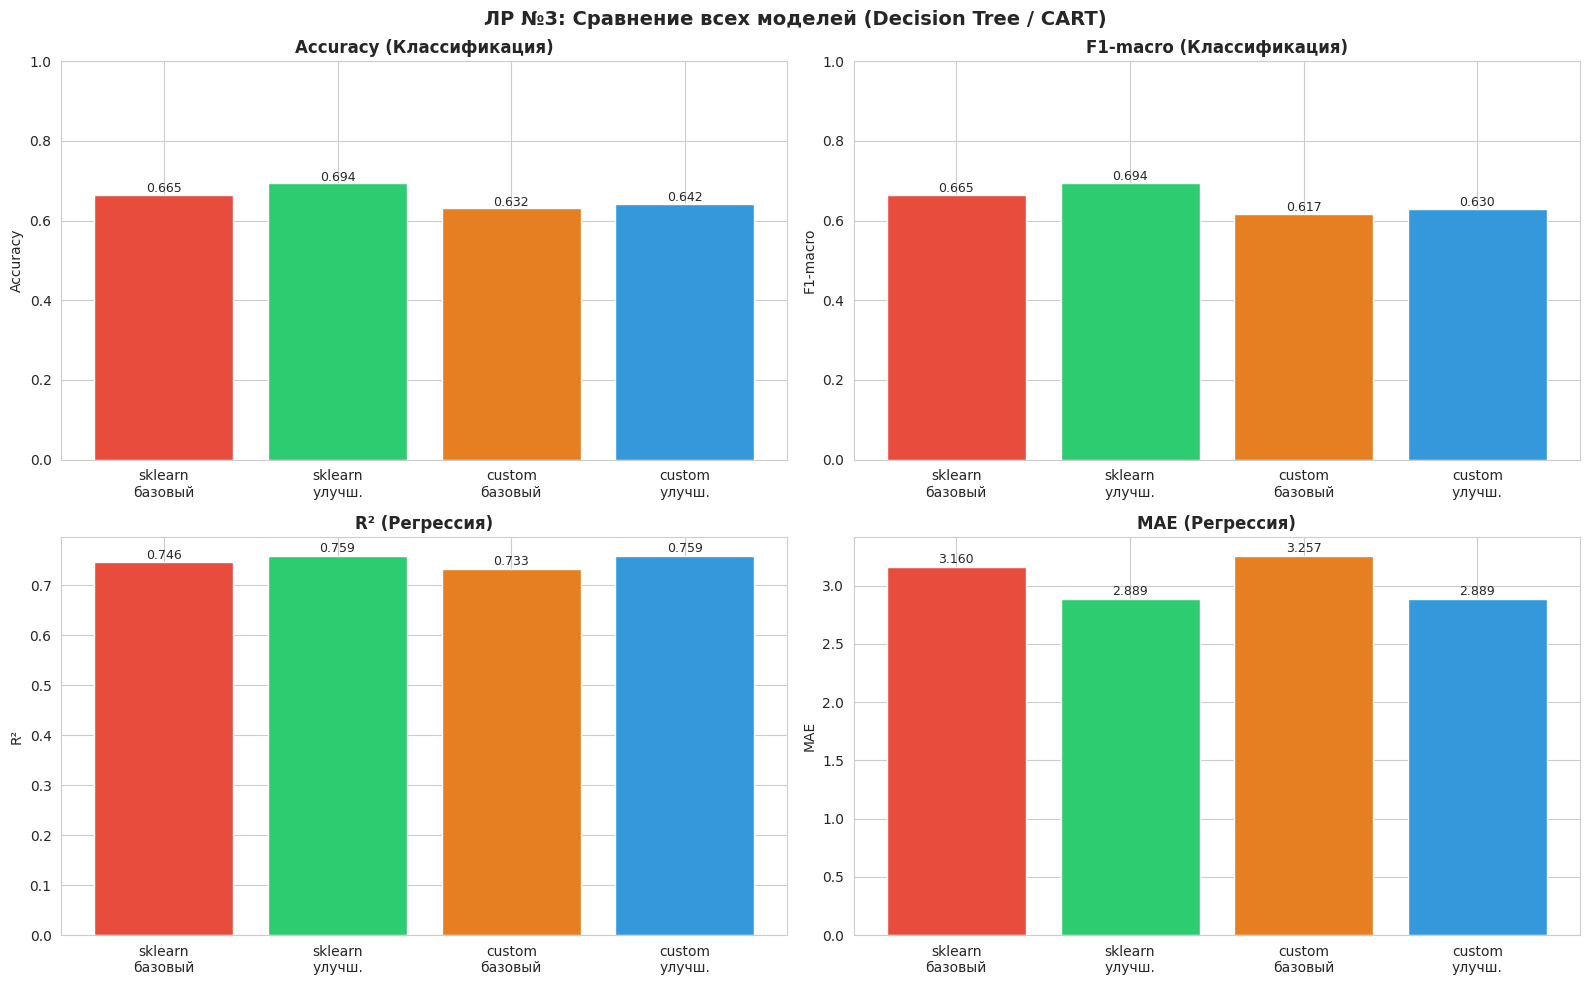

In [ ]:
# Финальный дашборд: все 4 модели по всем ключевым метрикам

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels = ['sklearn\nбазовый', 'sklearn\nулучш.', 'custom\nбазовый', 'custom\nулучш.']
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

def dash_bar(ax, vals, title, ylabel, ylim=None):
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontsize=9)

dash_bar(axes[0,0], [acc_dt_base, acc_dt_improved, acc_my_base, acc_my_impr],
         'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
dash_bar(axes[0,1], [f1_dt_base, f1_dt_improved, f1_my_base, f1_my_impr],
         'F1-macro (Классификация)', 'F1-macro', ylim=(0, 1))
dash_bar(axes[1,0], [r2_dt_base, r2_dt_improved, r2_my_base, r2_my_impr],
         'R² (Регрессия)', 'R²')
dash_bar(axes[1,1], [mae_dt_base, mae_dt_improved, mae_my_base, mae_my_impr],
         'MAE (Регрессия)', 'MAE')

plt.suptitle('ЛР №3: Сравнение всех моделей (Decision Tree / CART)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Итоговые выводы

### 4e. Собственная базовая CART vs sklearn (п.2)
- Собственная реализация CART корректно воспроизводит поведение sklearn: без ограничений оба дерева глубоко переобучаются (train R² ≈ 1.0, test R² значительно ниже).
- Распределение важности признаков совпадает между реализациями, что подтверждает корректность вычисления information gain.
- Небольшие расхождения в метриках объясняются различиями в порядке перебора признаков при равном gain и обработке пороговых значений.

### 4j. Улучшенная собственная CART vs улучшенный sklearn (п.3)
- Применение `max_depth`, `min_samples_leaf` и `min_samples_split` устранило переобучение: разрыв train/test существенно сократился.
- Наибольший прирост качества дало ограничение глубины — это ключевой гиперпараметр решающего дерева.
- Улучшенная собственная реализация вплотную приближается к результатам sklearn, подтверждая правильность алгоритма.
- **Решающее дерево интерпретируемо:** визуализация структуры дерева и важности признаков позволяет объяснить предсказания — преимущество перед KNN и линейной регрессией.